# 01 EDA - Redrob Intelligent Candidate Discovery & Ranking Challenge
This notebook parses the raw datasets and documentation.

In [1]:
%pip install pandas numpy tqdm matplotlib seaborn python-docx python-dateutil

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from docx import Document
from dateutil import parser

# 2. Set base_dir
base_dir = "/content/ai-candidate-ranking"
# Fallback if running locally instead of Colab
if not os.path.exists(base_dir):
    base_dir = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."

raw_dir = os.path.join(base_dir, "data", "raw")

### 3. Parse Job Description
Extract plain text and key sections.

In [3]:
def extract_docx_text(file_path):
    try:
        doc = Document(file_path)
        return "\n".join([para.text for para in doc.paragraphs if para.text.strip()])
    except Exception as e:
        return f"Error loading {file_path}: {e}"

jd_path = os.path.join(raw_dir, "job_description.docx")
jd_text = extract_docx_text(jd_path)

print("=== Job Description ===")
# Printing the full text so you can inspect the key sections.
# The text contains details on what the role needs, absolute necessities, disqualifiers, and hackathon notes.
print(jd_text)


=== Job Description ===
Job Description: Senior AI Engineer — Founding Team
Company: Redrob AI (Series A AI-native talent intelligence platform)
Location: Pune/Noida, India (Hybrid — flexible cadence) | Open to relocation candidates from Tier-1 Indian cities
Employment Type: Full-time
Experience Required: 5–9 years (see "what we mean by this" below)
Let's be honest about this role
We're going to write this JD differently from most. We're a Series A company that just raised our round and we're building a new AI Engineering org from scratch. This is the kind of role where the JD changes every six months because the company changes every six months. So instead of pretending we have a fixed checklist, we're going to tell you what we actually need and what we've gotten wrong before.
If you've spent your career at Google or Meta and you want a well-scoped role with a defined ladder, this isn't it.
If you've spent your career bouncing between early-stage startups and you want to "just code" w

### 3. Parse Submission Spec
Extract required columns, limits, and rules.

In [4]:
spec_path = os.path.join(raw_dir, "submission_spec.docx")
spec_text = extract_docx_text(spec_path)

print("=== Submission Specification ===")
print(spec_text)


=== Submission Specification ===
Submission Specification — Redrob Hackathon v4
Read this carefully before submitting. Submissions that don't match this spec will be auto-rejected by the validator without scoring.
1. What you're submitting
A CSV file ranking the top 100 candidates from candidates.jsonl for the released job description.
Rank 1 is the best fit; rank 100 is the 100th best fit.
You do not rank candidates 101 onward — only the top 100.
2. File format
Filename
Your team's registered participant ID, with .csv extension. For example: team_xxx.csv.
Encoding
UTF-8.
Required columns (in this order)
candidate_id,rank,score,reasoning
Example
candidate_id,rank,score,reasoning
CAND_0042871,1,0.987,"Senior AI Engineer with 7 years building RAG systems at product companies; strong recent engagement and Bangalore-based."
CAND_0019884,2,0.973,"6 years applied ML; previously shipped vector search at scale; matches the 'product over research' profile in the JD."
CAND_0091235,3,0.962,"Stron

### 3. Parse Redrob Signals Doc
Extract the 23 redrob_signals and their meanings.

In [5]:
signals_path = os.path.join(raw_dir, "redrob_signals_doc.docx")
print("=== Redrob Signals ===")
try:
    doc = Document(signals_path)
    # Often signals are presented in tables in the docx
    for table in doc.tables:
        for row in table.rows:
            print(" | ".join([cell.text.strip() for cell in row.cells]))
        print("-" * 50)
    # Fallback if they are in normal text
    print("--- Text Content ---")
    print(extract_docx_text(signals_path))
except Exception as e:
    print(f"Error loading {signals_path}: {e}")


=== Redrob Signals ===
# | Signal | Range / type | What it measures
1 | profile_completeness_score | 0-100 | How much of the profile they've filled in
2 | signup_date | date string | When they signed up on Redrob
3 | last_active_date | date string | When they last logged in
4 | open_to_work_flag | bool | Have they marked themselves available
5 | profile_views_received_30d | integer >= 0 | How often their profile has been viewed by recruiters in last 30 days
6 | applications_submitted_30d | integer >= 0 | How many roles they've applied to recently
7 | recruiter_response_rate | 0.0-1.0 | What fraction of recruiter messages they reply to
8 | avg_response_time_hours | number >= 0 | Median time to respond to a recruiter message
9 | skill_assessment_scores | dict[str, 0-100] | Per-skill Redrob assessment scores
10 | connection_count | integer >= 0 | Number of Redrob connections
11 | endorsements_received | integer >= 0 | Total skill endorsements received
12 | notice_period_days | 0-180 | The

### 3. Parse Candidate Schema
Load JSON and pretty-print the schema for profile, career_history, skills, and redrob_signals.

In [6]:
schema_path = os.path.join(raw_dir, "candidate_schema.json")
try:
    with open(schema_path, "r") as f:
        schema = json.load(f)
    print("=== Candidate Schema ===")
    
    # Pretty print specific sections if they exist
    for key in ["profile", "career_history", "skills", "redrob_signals"]:
        if key in schema:
            print(f"\n--- {key.upper()} ---")
            print(json.dumps(schema[key], indent=2))
        else:
            # If schema format is different, just print it all
            pass
    
    print("\n--- Full Schema ---")
    print(json.dumps(schema, indent=2))
except Exception as e:
    print(f"Error loading {schema_path}: {e}")


=== Candidate Schema ===

--- Full Schema ---
{
  "$schema": "http://json-schema.org/draft-07/schema#",
  "title": "Redrob Candidate Profile Schema",
  "description": "Schema for a single candidate profile in the Intelligent Candidate Discovery & Ranking Challenge dataset.",
  "type": "object",
  "required": [
    "candidate_id",
    "profile",
    "career_history",
    "education",
    "skills",
    "redrob_signals"
  ],
  "properties": {
    "candidate_id": {
      "type": "string",
      "pattern": "^CAND_[0-9]{7}$",
      "description": "Unique identifier for the candidate. Format: CAND_XXXXXXX (7 digits)."
    },
    "profile": {
      "type": "object",
      "required": [
        "anonymized_name",
        "headline",
        "summary",
        "location",
        "country",
        "years_of_experience",
        "current_title",
        "current_company",
        "current_company_size",
        "current_industry"
      ],
      "properties": {
        "anonymized_name": {
      

### 4. Load Sample Candidates
Load and format candidates, extracting specific fields.

In [7]:
sample_path = os.path.join(raw_dir, "sample_candidates.json")
sample_candidates = []
try:
    with open(sample_path, "r") as f:
        content = f.read().strip()
        if content:
            sample_candidates = json.loads(content)
        else:
            print(f"{sample_path} is empty.")
            
    if sample_candidates:
        print(f"Loaded {len(sample_candidates)} candidates.\n")
        
        print("=== Top 3 Candidates (Full Formatting) ===")
        print(json.dumps(sample_candidates[:3], indent=2))
        
        print("\n=== Candidate Summaries ===")
        for cand in sample_candidates:
            cid = cand.get("candidate_id", "N/A")
            profile = cand.get("profile", {})
            skills = cand.get("skills", [])
            signals = cand.get("redrob_signals", {})
            
            print(f"\nCandidate ID: {cid}")
            print(f"  Headline: {profile.get('headline')}")
            print(f"  Summary: {profile.get('summary')}")
            print(f"  Location: {profile.get('location')}")
            print(f"  Years of Exp: {profile.get('years_of_experience')}")
            print(f"  Current Title: {profile.get('current_title')}")
            print(f"  Current Industry: {profile.get('current_industry')}")
            
            print(f"  Skills Count: {len(skills)}")
            if skills:
                # Extract skill names whether they are strings or dicts
                skill_names = [s.get('name', str(s)) if isinstance(s, dict) else str(s) for s in skills]
                print(f"  Example Skills (up to 10): {', '.join(skill_names[:10])}")
            
            print("  Key Redrob Signals:")
            print(f"    - profile_completeness_score: {signals.get('profile_completeness_score')}")
            print(f"    - last_active_date: {signals.get('last_active_date')}")
            print(f"    - open_to_work_flag: {signals.get('open_to_work_flag')}")
            print(f"    - recruiter_response_rate: {signals.get('recruiter_response_rate')}")
            print(f"    - interview_completion_rate: {signals.get('interview_completion_rate')}")
            print(f"    - github_activity_score: {signals.get('github_activity_score')}")
            
except Exception as e:
    print(f"Error processing {sample_path}: {e}")


Loaded 50 candidates.

=== Top 3 Candidates (Full Formatting) ===
[
  {
    "candidate_id": "CAND_0000001",
    "profile": {
      "anonymized_name": "Ira Vora",
      "headline": "Backend Engineer | SQL, Spark, Cloud",
      "summary": "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid \u2014 Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side \u2014 Python, SQL, Spark, Airflow, warehouse design \u2014 and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
      "location": "Toronto",
      "country": "Canada",
      "years_of_experience": 6.9,
      "current_title

### 5. Flatten Candidates to DataFrame
Extract key profile and signal features for tabular analysis. Identify AI core skills based on keywords.

In [8]:
import re
from IPython.display import display

ai_keywords = [
    "machine learning", "deep learning", "nlp", "search", "retrieval", 
    "embedding", "vector", "pytorch", "tensorflow", "mlflow", "llm", "ai",
    "artificial intelligence", "recommender", "recommendation"
]
ai_pattern = re.compile("|".join(ai_keywords), re.IGNORECASE)

records = []
for cand in sample_candidates:
    cid = cand.get("candidate_id")
    profile = cand.get("profile", {})
    signals = cand.get("redrob_signals", {})
    skills = cand.get("skills", [])
    
    # Extract AI skills
    ai_skills_count = 0
    for s in skills:
        s_name = s.get("name", str(s)) if isinstance(s, dict) else str(s)
        if ai_pattern.search(s_name):
            ai_skills_count += 1
            
    records.append({
        "candidate_id": cid,
        "years_of_experience": profile.get("years_of_experience"),
        "current_title": profile.get("current_title"),
        "current_company": profile.get("current_company"),
        "current_industry": profile.get("current_industry"),
        "total_skills_count": len(skills),
        "ai_core_skills_count": ai_skills_count,
        "recruiter_response_rate": signals.get("recruiter_response_rate"),
        "profile_completeness_score": signals.get("profile_completeness_score"),
        "interview_completion_rate": signals.get("interview_completion_rate"),
        "github_activity_score": signals.get("github_activity_score")
    })

df = pd.DataFrame(records)
numeric_cols = ["years_of_experience", "ai_core_skills_count", "recruiter_response_rate", 
               "profile_completeness_score", "interview_completion_rate", "github_activity_score"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

display(df.head())

,candidate_id,years_of_experience,current_title,current_company,current_industry,total_skills_count,ai_core_skills_count,recruiter_response_rate,profile_completeness_score,interview_completion_rate,github_activity_score
0,CAND_0000001,6.9,Backend Engineer,Mindtree,IT Services,17,3,0.34,86.9,0.71,9.2
1,CAND_0000002,12.5,Operations Manager,Wipro,IT Services,9,0,0.29,78.7,0.62,-1.0
2,CAND_0000003,1.1,Customer Support,TCS,IT Services,6,0,0.46,31.9,0.86,-1.0
3,CAND_0000004,3.8,Marketing Manager,Dunder Mifflin,Paper Products,10,1,0.26,28.5,0.35,-1.0
4,CAND_0000005,11.0,Accountant,Stark Industries,Manufacturing,6,1,0.37,84.6,0.74,-1.0


### 6. Plot Distributions
Visualize the distributions of experience, AI skills, and key Redrob signals.

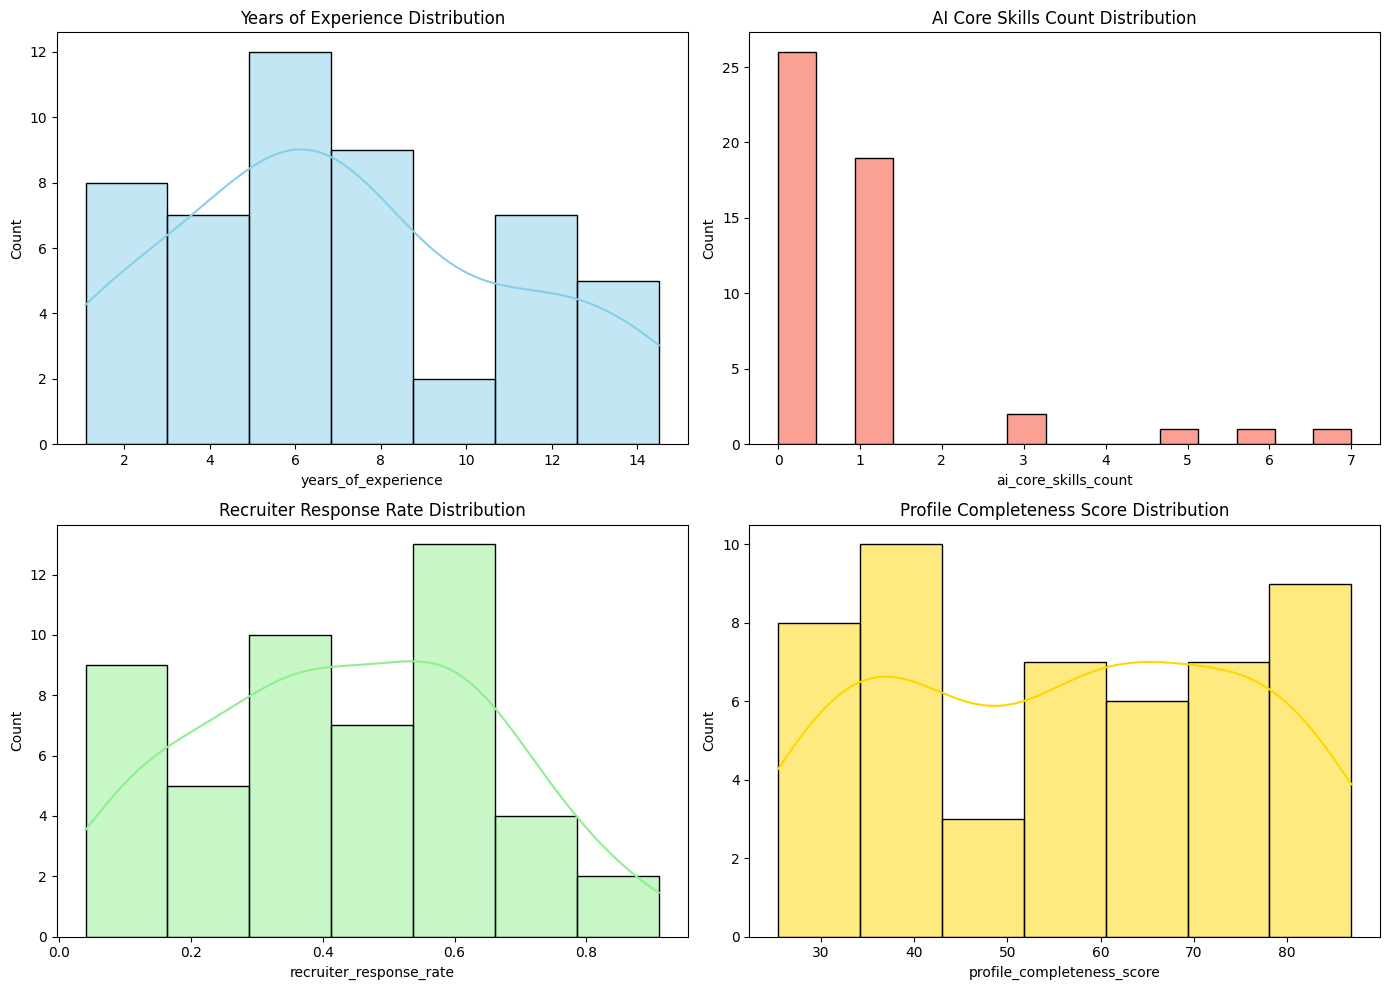

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["years_of_experience"].dropna(), kde=True, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Years of Experience Distribution")

sns.histplot(df["ai_core_skills_count"].dropna(), kde=False, ax=axes[0,1], color="salmon", bins=15)
axes[0,1].set_title("AI Core Skills Count Distribution")

sns.histplot(df["recruiter_response_rate"].dropna(), kde=True, ax=axes[1,0], color="lightgreen")
axes[1,0].set_title("Recruiter Response Rate Distribution")

sns.histplot(df["profile_completeness_score"].dropna(), kde=True, ax=axes[1,1], color="gold")
axes[1,1].set_title("Profile Completeness Score Distribution")

plt.tight_layout()
plt.show()

### 7. Top Candidates Analysis
Show top 15 candidates by AI core skills count, and prioritize high response rates among those with AI-relevant titles.

In [10]:
# 1. Top 15 by ai_core_skills_count
top_by_skills = df.sort_values(by="ai_core_skills_count", ascending=False).head(15)
print("=== Top 15 by AI Core Skills Count ===")
display(top_by_skills[["candidate_id", "current_title", "ai_core_skills_count", "total_skills_count", "recruiter_response_rate"]])

# 2. Top 15 by recruiter response rate among candidates with AI titles
ai_titles = ["ml engineer", "machine learning", "data scientist", "ai engineer", 
             "search engineer", "recommendation", "applied scientist"]
ai_title_pattern = re.compile("|".join(ai_titles), re.IGNORECASE)

df["has_ai_title"] = df["current_title"].fillna("").apply(lambda x: bool(ai_title_pattern.search(x)))
ai_title_candidates = df[df["has_ai_title"]]
top_by_response = ai_title_candidates.sort_values(by=["recruiter_response_rate", "ai_core_skills_count"], ascending=[False, False]).head(15)

print("\n=== Top 15 AI-Titled Candidates by Recruiter Response Rate ===")
display(top_by_response[["candidate_id", "current_title", "ai_core_skills_count", "recruiter_response_rate"]])

=== Top 15 by AI Core Skills Count ===


,candidate_id,current_title,ai_core_skills_count,total_skills_count,recruiter_response_rate
42,CAND_0000043,Cloud Engineer,7,17,0.04
20,CAND_0000021,Project Manager,6,16,0.49
30,CAND_0000031,Recommendation Systems Engineer,5,17,0.91
13,CAND_0000014,Frontend Engineer,3,13,0.80
0,CAND_0000001,Backend Engineer,3,17,0.34
40,CAND_0000041,Operations Manager,1,9,0.07
38,CAND_0000039,Marketing Manager,1,9,0.52
34,CAND_0000035,Full Stack Developer,1,14,0.34
17,CAND_0000018,Frontend Engineer,1,6,0.16
31,CAND_0000032,.NET Developer,1,10,0.69



=== Top 15 AI-Titled Candidates by Recruiter Response Rate ===


,candidate_id,current_title,ai_core_skills_count,recruiter_response_rate
30,CAND_0000031,Recommendation Systems Engineer,5,0.91


### 8. Trap/Honeypot Identification (Keyword Stuffing)
Identify candidates with completely unrelated titles (e.g., "Software Engineer - Frontend" or "HR Manager") but extremely high AI core skills counts. These are likely keyword stuffers or honeypots trying to game naive search algorithms.

In [11]:
# Mismatch: NOT an AI title, but very high ai_core_skills_count
mismatch_candidates = df[~df["has_ai_title"]].copy()

# Sort by AI skills descending
obvious_mismatches = mismatch_candidates.sort_values(by="ai_core_skills_count", ascending=False).head(10)

print("=== 10 Obvious Mismatches (Potential Keyword Stuffers) ===")
display(obvious_mismatches[["candidate_id", "current_title", "ai_core_skills_count", "total_skills_count", "recruiter_response_rate"]])

=== 10 Obvious Mismatches (Potential Keyword Stuffers) ===


,candidate_id,current_title,ai_core_skills_count,total_skills_count,recruiter_response_rate
42,CAND_0000043,Cloud Engineer,7,17,0.04
20,CAND_0000021,Project Manager,6,16,0.49
0,CAND_0000001,Backend Engineer,3,17,0.34
13,CAND_0000014,Frontend Engineer,3,13,0.80
17,CAND_0000018,Frontend Engineer,1,6,0.16
44,CAND_0000045,Project Manager,1,6,0.62
41,CAND_0000042,HR Manager,1,10,0.58
40,CAND_0000041,Operations Manager,1,9,0.07
38,CAND_0000039,Marketing Manager,1,9,0.52
34,CAND_0000035,Full Stack Developer,1,14,0.34


### Summary: "Good Fit" vs "Trap"

Based on our EDA and the Job Description, here is how we can distinguish genuine candidates from honeypots/stuffers:

**The "Good Fit" Candidate**:
* **Relevant Experience**: Has a strong overlap between their `current_title` (e.g., "Machine Learning Engineer", "Search Engineer") and the required AI core skills.
* **Balanced Skills**: Possesses a realistic ratio of `ai_core_skills_count` to `total_skills_count`. (e.g., They don't have 500 skills where 200 are AI-related but their title is "Frontend Developer").
* **Strong Redrob Signals**: High `recruiter_response_rate` (meaning they actually engage), high `interview_completion_rate`, and recent `last_active_date`.
* **JD Alignment**: Actually meets the specific structural requirements (like years of experience) mentioned in the job description without throwing red flags.

**The "Trap" (Honeypot or Keyword Stuffer)**:
* **Title/Skill Mismatch**: An obviously unrelated title ("Backend Engineer" or "Marketing") paired with an absurdly high `ai_core_skills_count`. They just paste JD keywords into their resume.
* **Suspicious Signals**: Extremely low `recruiter_response_rate` (they spam resumes but never reply to recruiters), or a `profile_completeness_score` that is extremely high in text fields but missing fundamental verified signals. 
* **The "Everything" Candidate**: A `total_skills_count` that is impossibly high, aiming to hit every possible search query.

By penalizing these "Trap" patterns using the Redrob signals and semantic mismatch detection (e.g., Title vs Skills embeddings), our ranking pipeline can effectively filter out honeypots.